Flux shape: (122, 9216)
Wavelength shape: (122, 9216)


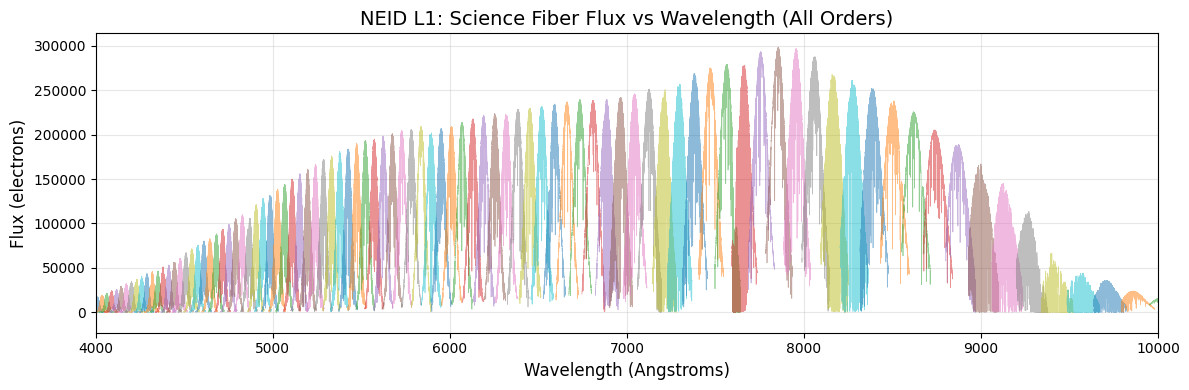

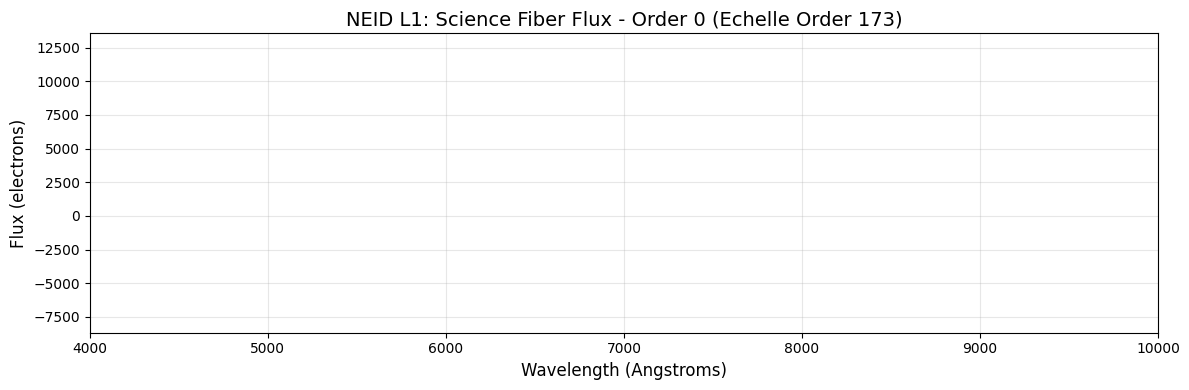

In [6]:
import numpy as np
import matplotlib.pyplot as plt
from astropy.io import fits

# Open the FITS file
fits_file = 'neidL1_20240630T210459.fits'
hdul = fits.open(fits_file)

# According to the documentation:
# HDU 1: 1D science fiber flux in electrons
# HDU 7: Science fiber vacuum wavelength in Angstroms

# Read the data
flux = hdul[1].data  # Science fiber flux
wavelength = hdul[7].data  # Science fiber wavelength

# Print shapes to understand the data structure
print(f"Flux shape: {flux.shape}")
print(f"Wavelength shape: {wavelength.shape}")

# If the data is 2D (122 orders), you can plot all orders or select one
if len(flux.shape) == 2:
    # Plot all orders
    plt.figure(figsize=(12, 4))
    for i in range(flux.shape[0]):
        plt.plot(wavelength[i], flux[i], alpha=0.5, linewidth=0.5)
    plt.xlabel('Wavelength (Angstroms)', fontsize=12)
    plt.ylabel('Flux (electrons)', fontsize=12)
    plt.title('NEID L1: Science Fiber Flux vs Wavelength (All Orders)', fontsize=14)
    plt.xlim(4000, 10000)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()
    
    # Or plot a specific order (e.g., order 0 which corresponds to echelle order 173)
    plt.figure(figsize=(12, 4))
    order_index = 0
    plt.plot(wavelength[order_index], flux[order_index])
    plt.xlabel('Wavelength (Angstroms)', fontsize=12)
    plt.ylabel('Flux (electrons)', fontsize=12)
    plt.title(f'NEID L1: Science Fiber Flux - Order {order_index} (Echelle Order 173)', fontsize=14)
    plt.xlim(4000, 10000)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()
else:
    # If 1D data
    plt.figure(figsize=(12, 4))
    plt.plot(wavelength, flux)
    plt.xlabel('Wavelength (Angstroms)', fontsize=12)
    plt.ylabel('Flux (electrons)', fontsize=12)
    plt.title('NEID L1: Science Fiber Flux vs Wavelength', fontsize=14)
    plt.xlim(4000, 10000)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

# Close the FITS file
hdul.close()


In [7]:
from astropy.io import fits

fits_file = 'neidL1_20240630T210459.fits'
hdul = fits.open(fits_file)

# List all HDUs to find blaze-related extensions
hdul.info()

# Look for HDUs that might contain blaze function
for i, hdu in enumerate(hdul):
    print(f"HDU {i}: {hdu.name}")
    if hdu.header.get('EXTNAME'):
        print(f"  Extension name: {hdu.header['EXTNAME']}")

Filename: neidL1_20240630T210459.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU     749   ()      
  1  SCIFLUX       1 ImageHDU        13   (9216, 122)   float64   
  2  SKYFLUX       1 ImageHDU        13   (9216, 122)   float64   
  3  CALFLUX       1 ImageHDU        13   (9216, 122)   float64   
  4  SCIVAR        1 ImageHDU        12   (9216, 122)   float32   
  5  SKYVAR        1 ImageHDU        12   (9216, 122)   float32   
  6  CALVAR        1 ImageHDU        12   (9216, 122)   float32   
  7  SCIWAVE       1 ImageHDU      2451   (9216, 122)   float64   
  8  SKYWAVE       1 ImageHDU      2451   (9216, 122)   float64   
  9  CALWAVE       1 ImageHDU      2451   (9216, 122)   float64   
HDU 0: PRIMARY
HDU 1: SCIFLUX
  Extension name: SCIFLUX
HDU 2: SKYFLUX
  Extension name: SKYFLUX
HDU 3: CALFLUX
  Extension name: CALFLUX
HDU 4: SCIVAR
  Extension name: SCIVAR
HDU 5: SKYVAR
  Extension name: SKYVAR
HDU 6: CALVAR
  Extension name